0.9917794673380413 0.32925839193709966 0.016210129258614807


d:\Anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


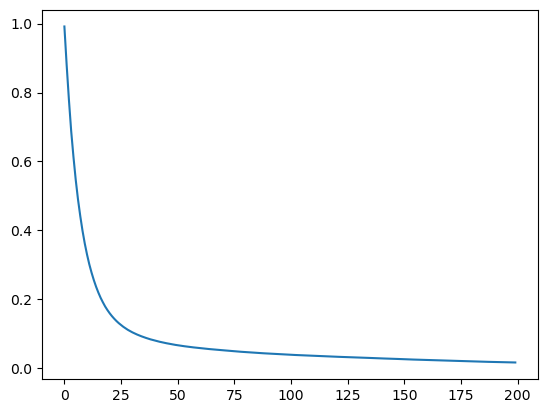

In [24]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X , y = load_breast_cancer(return_X_y=True)
X_tre , X_t , y_tre , y_t = train_test_split(X , y , test_size=0.2 , random_state=42)
scaler = StandardScaler()
X_t = scaler.fit_transform(X_t)
X_tre = scaler.transform(X_tre)

mlp = MLPClassifier(hidden_layer_sizes=(32,16) , max_iter=200 , random_state=42)
mlp.fit(X_tre , y_tre)
lc = mlp.loss_curve_
print(lc[0] , lc[10] , lc[-1])

from matplotlib import pyplot as plt
plt.plot(lc)
plt.show()

# Learning rate 

In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc = StandardScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

0.0001 0.202 0.947


d:\Anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


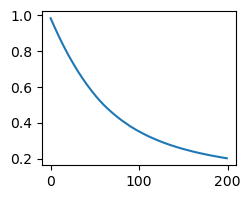

0.001 0.036 0.956


d:\Anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


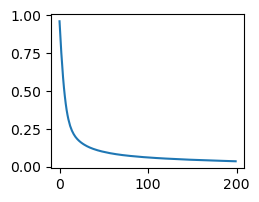

0.01 0.003 0.956


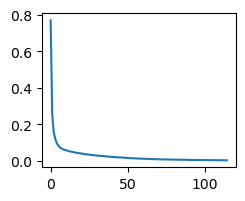

0.1 0.001 0.956


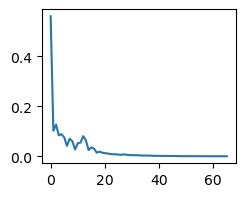

1.0 0.012 0.956


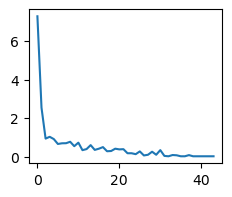

In [26]:
for lr in [0.0001, 0.001, 0.01, 0.1, 1.0]:
    mlp = MLPClassifier(hidden_layer_sizes=(32,), learning_rate_init=lr,
                        max_iter=200, random_state=42).fit(X_tr, y_tr)
    print(lr , round(mlp.loss_curve_[-1] , 3) , round(mlp.score(X_te , y_te) , 3))
    plt.figure(figsize=(2.5,2))
    plt.plot(mlp.loss_curve_)
    plt.show()

# Noisy Data : Knowing when to stop

In [ ]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

x , Y = make_classification(n_samples=600 , n_features=40 , n_informative=5 , flip_y=0.15 , class_sep=0.7 , random_state=0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
sc = StandardScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

big = dict(hidden_layer_sizes = (200,200) , max_iter = 1000 , random_state = 0)

plain = MLPClassifier(**big).fit(X_tr ,y_tr)
stopped = MLPClassifier(early_stopping=True , validation_fraction= 0.2 ,**big).fit(X_tr , y_tr)

print(plain.score(X_te , y_te))
print(stopped.score(X_te , y_te))


0.9649122807017544
0.9210526315789473
